<h2>🚀 NSL-KDD Intrusion Detection - Data Preprocessing & ML Models</h2>

<p>
This notebook demonstrates a full workflow on the <b>NSL-KDD dataset</b>, 
covering preprocessing, scaling, training, and evaluating multiple ML models.
</p>

<h3>Steps covered:</h3>
<ol>
  <li>Load and explore dataset</li>
  <li>Clean missing and duplicate rows</li>
  <li>Handle categorical features with one-hot encoding</li>
  <li>Normalize features using MinMaxScaler</li>
  <li>Create binary target (Normal vs Attack)</li>
  <li>Split into train & test sets</li>
  <li>Train multiple ML models</li>
  <li>Evaluate and compare performance</li>
</ol>


<h3> Step 1: Import Libraries </h3>

In [ ]:
# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


<h3> Step 2: Load Dataset </h3>

In [50]:
# Step 2: Load Dataset
file_path = "../data/KDDTrain+.txt"
train_df = pd.read_csv(file_path, header=None)
test_df = pd.read_csv('../data/KDDTest+.txt', header=None, names=columns)


# Assign column names
columns = [
    'duration','protocol_type','service','flag','src_bytes','dst_bytes','land','wrong_fragment','urgent','hot',
    'num_failed_logins','logged_in','num_compromised','root_shell','su_attempted','num_root','num_file_creations',
    'num_shells','num_access_files','num_outbound_cmds','is_host_login','is_guest_login','count','srv_count',
    'serror_rate','srv_serror_rate','rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate','srv_diff_host_rate',
    'dst_host_count','dst_host_srv_count','dst_host_same_srv_rate','dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate','dst_host_srv_diff_host_rate','dst_host_serror_rate',
    'dst_host_srv_serror_rate','dst_host_rerror_rate','dst_host_srv_rerror_rate','label','difficulty_level'
]
df.columns = columns

print("Dataset shape:", df.shape)
df.head()


Dataset shape: (125973, 43)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty_level
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


<h3> Step 3: Data Cleaning </h3>

In [53]:
print("Missing values in train set:", train_df.isnull().sum().sum())
print("Missing values in test set:", test_df.isnull().sum().sum())

train_df = train_df.dropna()
test_df = test_df.dropna()

before = train_df.shape[0]
train_df = train_df.drop_duplicates()
after = train_df.shape[0]
print(f"Removed {before - after} duplicate rows from train data. Final shape: {train_df.shape}")

before_test = test_df.shape[0]
test_df = test_df.drop_duplicates()
after_test = test_df.shape[0]
print(f"Removed {before_test - after_test} duplicate rows from test data. Final shape: {test_df.shape}")


Missing values in train set: 0
Missing values in test set: 0
Removed 0 duplicate rows from train data. Final shape: (125973, 43)
Removed 0 duplicate rows from test data. Final shape: (22544, 43)


<h3> Step 4: Encode Categorical Features</h3>


In [ ]:
# Step 5: One-Hot Encode categorical columns
categorical_cols = ['protocol_type', 'service', 'flag']

# Check if columns exist:
for col in categorical_cols:
    if col not in train_df.columns:
        print(f"Column {col} not found in training data columns!")

# Strip whitespace if needed
train_df.columns = train_df.columns.str.strip()
test_df.columns = test_df.columns.str.strip()

# Apply get_dummies after ensuring columns exist
train_df = pd.get_dummies(train_df, columns=categorical_cols, drop_first=True)
test_df = pd.get_dummies(test_df, columns=categorical_cols, drop_first=True)


KeyError: "None of [Index(['protocol_type', 'service', 'flag'], dtype='object')] are in the [columns]"

<h3> Step 5: Feature Scaling</h3>


In [5]:
scaler = MinMaxScaler()
numeric_cols = df.drop(columns=['label']).columns
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])
df.head()


,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,flag_REJ,flag_RSTO,flag_RSTOS0,flag_RSTR,flag_S0,flag_S1,flag_S2,flag_S3,flag_SF,flag_SH
0,0.0,3.558064e-07,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.0,1.057999e-07,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.0,0.000000e+00,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,0.0,1.681203e-07,6.223962e-06,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.0,1.442067e-07,3.206260e-07,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


<h3> Step 6: Create Target Variable (Train-Test Split)</h3>



In [7]:
# Create binary target column: 0 = Normal, 1 = Attack
df = df.copy()  
df['attack_binary'] = df['label'].apply(lambda x: 0 if x == 'normal' else 1)

# Define features and target
X = df.drop(columns=['label','attack_binary','difficulty_level'])
y = df['attack_binary']

# Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set:", X_train.shape, " Test set:", X_test.shape)


Training set: (100778, 119)  Test set: (25195, 119)


<h3> Step 7: Exploratory Data Analysis (EDA)</h3>


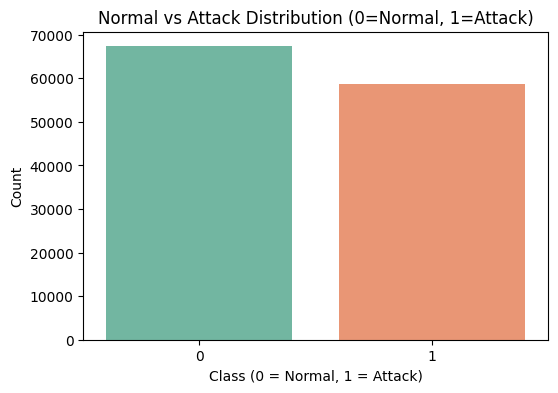

In [18]:
# Normal vs Attack distribution with Seaborn pastel palette
plt.figure(figsize=(6,4))
sns.countplot(x='attack_binary', hue='attack_binary', data=df, palette="Set2", legend=False)

plt.title("Normal vs Attack Distribution (0=Normal, 1=Attack)", fontsize=12)
plt.xlabel("Class (0 = Normal, 1 = Attack)")
plt.ylabel("Count")
plt.show()


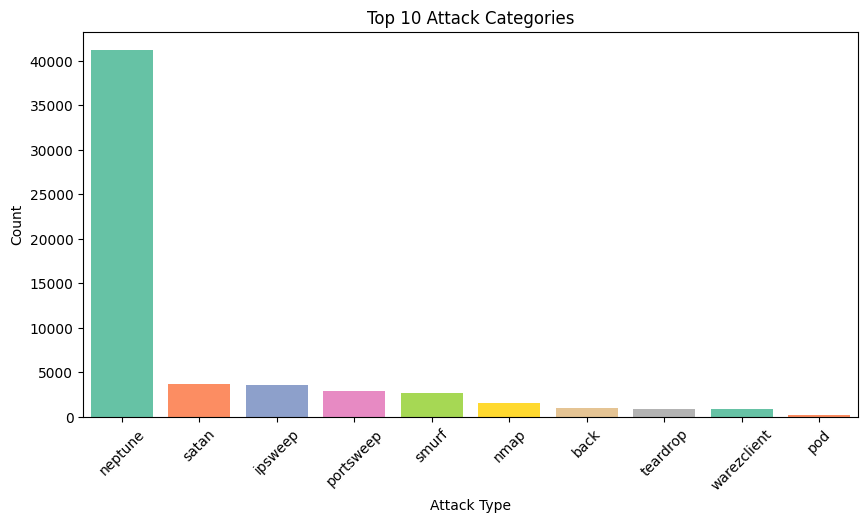

In [27]:
# Top 10 attack categories 
attack_counts = df[df['label'] != 'normal']['label'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(
    x=attack_counts.index, 
    y=attack_counts.values, 
    color=None,  
    palette=None
)


colors = sns.color_palette("Set2", len(attack_counts))
for i, bar in enumerate(plt.gca().patches):
    bar.set_facecolor(colors[i])

plt.title("Top 10 Attack Categories", fontsize=12)
plt.xlabel("Attack Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()


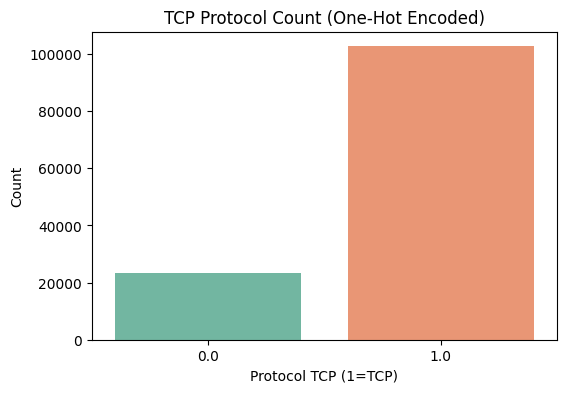

In [31]:
# Protocol distribution (Seaborn Set2 palette)
plt.figure(figsize=(6,4))
sns.countplot(
    x='protocol_type_tcp', 
    data=df, 
    hue='protocol_type_tcp',  
    palette="Set2",
    dodge=False,              
    legend=False
)
plt.title("TCP Protocol Count (One-Hot Encoded)", fontsize=12)
plt.xlabel("Protocol TCP (1=TCP)")
plt.ylabel("Count")
plt.show()


<h3> Step 7: Train Multiple Models</h3>


In [34]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=120, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

results = {}

for name, model in models.items():
    print(f"\n🔹 Training {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"{name} Accuracy: {acc*100:.2f}%")
    print(classification_report(y_test, y_pred, target_names=["Normal","Attack"]))



🔹 Training Logistic Regression...
Logistic Regression Accuracy: 96.96%
              precision    recall  f1-score   support

      Normal       0.96      0.98      0.97     13469
      Attack       0.98      0.96      0.97     11726

    accuracy                           0.97     25195
   macro avg       0.97      0.97      0.97     25195
weighted avg       0.97      0.97      0.97     25195


🔹 Training Decision Tree...
Decision Tree Accuracy: 99.87%
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     13469
      Attack       1.00      1.00      1.00     11726

    accuracy                           1.00     25195
   macro avg       1.00      1.00      1.00     25195
weighted avg       1.00      1.00      1.00     25195


🔹 Training Random Forest...
Random Forest Accuracy: 99.90%
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     13469
      Attack       1.00      1.00      1.00  

<h3> Step 8: Model Accuracy Comparison</h3>


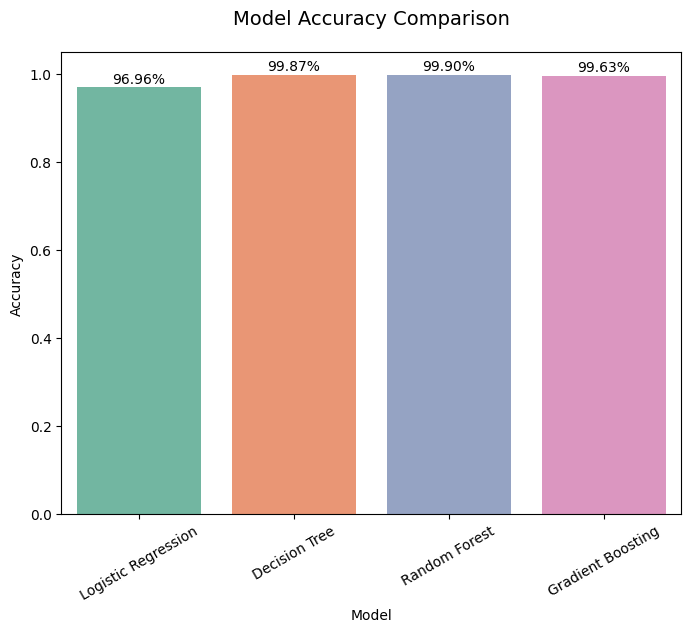

In [43]:
results_df = pd.DataFrame(list(results.items()), columns=["Model", "Accuracy"])

plt.figure(figsize=(8,6))  # Increased height
barplot = sns.barplot(
    x="Model",
    y="Accuracy",
    data=results_df,
    hue="Model",
    dodge=False,
    palette="Set2",
    legend=False
)

plt.title("Model Accuracy Comparison", fontsize=14, pad=20)  
plt.ylabel("Accuracy")
plt.ylim(0,1.05)  
plt.xticks(rotation=30)


for bar in barplot.patches:
    height = bar.get_height()
    barplot.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.01,  
        f"{height*100:.2f}%",
        ha='center',
        fontsize=10
    )

plt.show()


<h3> Step 9: Confusion Matrix (Random Forest)</h3>


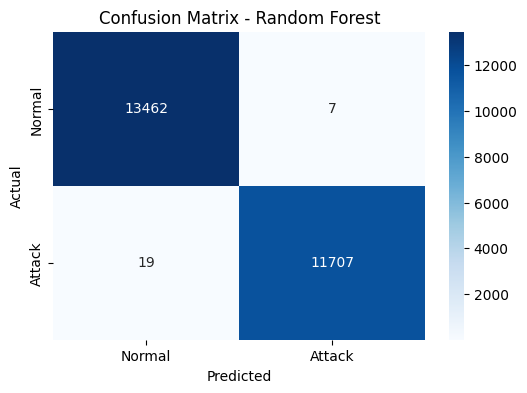

Random Forest Accuracy: 99.90%


In [46]:


# Predict with the best model
best_model = models["Random Forest"]
y_pred = best_model.predict(X_test)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot colorful confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues",
            xticklabels=['Normal', 'Attack'],
            yticklabels=['Normal', 'Attack'], cbar=True)
plt.title("Confusion Matrix - Random Forest", fontsize=12)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Print accuracy
accuracy = accuracy_score(y_test, y_pred) * 100
print(f"Random Forest Accuracy: {accuracy:.2f}%")
